CNN SIMPLE NOTEBOOK

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.8146 - loss: 0.5169 - val_accuracy: 0.8747 - val_loss: 0.3450
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8686 - loss: 0.3670 - val_accuracy: 0.8754 - val_loss: 0.3403
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8832 - loss: 0.3259 - val_accuracy: 0.8853 - val_loss: 0.3027
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8930 - loss: 0.2948 - val_accuracy: 0.8965 - val_loss: 0.2822
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9000 - loss: 0.2746 - val_accuracy: 0.8986 - val_loss: 0.2803
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9043 - loss: 0.2589 - val_accuracy: 0.9015 - val_loss: 0.2746
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9115 - loss: 0.2411 - val_accuracy: 0.9060 - val_loss: 0.2631
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9154 -

In [6]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8921 - loss: 0.3041
Accuracy: 0.8920999765396118


In [7]:
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[[752   2   7  19  11   1 205   0   3   0]
 [  2 978   0  13   1   0   4   0   2   0]
 [ 13   0 725   8 128   0 126   0   0   0]
 [ 17   4   6 903  32   0  36   0   2   0]
 [  0   0  20  22 909   0  47   0   2   0]
 [  0   0   0   0   0 990   0   8   0   2]
 [ 72   0  36  26  86   0 774   0   6   0]
 [  0   0   0   0   0  16   0 977   0   7]
 [  1   1   4   3   5   2   6   4 974   0]
 [  0   0   0   0   0   8   0  53   0 939]]


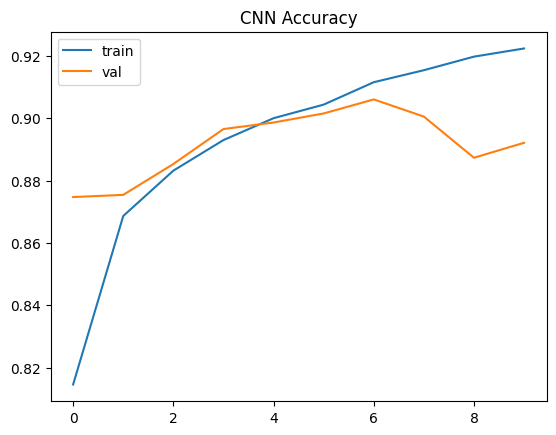

In [8]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("CNN Accuracy")
plt.show()